In [2]:
%cd MedCLIP-SAMv2/saliency_maps
!pip install -r colab_requirements.txt

/home/amina/amina/ws-bt-prelim/spring_03/resume/MedCLIP-SAM v2/MedCLIP-SAMv2/saliency_maps


/home/amina/miniforge3/envs/biomedclip/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-62b66m6o
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-62b66m6o
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached transformers-4.35.2-py3-none-any.whl.metadata (123 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 312.7 kB/s  0:00:25m0:00:0100:02
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
  Using cached tokenizers-0.15.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.7 kB)
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatib

In [1]:
import torch
import torchvision

In [2]:
%cd ../MedCLIP-SAMv2/MedCLIP-SAMv2/segment-anything

/home/amina/amina/ws-bt-prelim/spring_03/resume/MedCLIP-SAMv2/MedCLIP-SAMv2/segment-anything


/home/amina/miniforge3/envs/biomedclip/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())

PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
CUDA is available: False


In [4]:
%cd ..
%cd saliency_maps

/home/amina/amina/ws-bt-prelim/spring_03/resume/MedCLIP-SAMv2/MedCLIP-SAMv2
/home/amina/amina/ws-bt-prelim/spring_03/resume/MedCLIP-SAMv2/MedCLIP-SAMv2/saliency_maps


In [5]:
import warnings
warnings.filterwarnings('ignore')
import os
import torch
import clip
import cv2
import sys
import numpy as np
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt

from transformers import CLIPProcessor
from scripts.plot import generate_shades_with_alpha, plot_text_with_colors, visualize_vandt_heatmap
from scripts.methods import vision_heatmap_iba, text_heatmap_iba
from transformers import AutoModel, AutoProcessor, AutoTokenizer
from PIL import Image, ImageOps

In [6]:
os.environ["TOKENIZERS_PARALLELISM"] = "false"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [7]:
def plot(model, image, text, vbeta=0.1, vvar=1, vlayer=9, tbeta=0.1, tvar=1, tlayer=9):
    # Preprocess image
    image = Image.open(image).convert('RGB')
    image_feat = processor(images=image, return_tensors="pt")['pixel_values'].to(device) # 3*224*224
    # Tokenize text
    text_ids = torch.tensor([tokenizer.encode(text, add_special_tokens=True)]).to(device)
    text_words = tokenizer.convert_ids_to_tokens(text_ids[0].tolist())
    # Train information bottleneck on image
    print("Training M2IB on the image...")
    vmap = vision_heatmap_iba(text_ids, image_feat, model, vlayer, vbeta, vvar)
    # Train information bottleneck on text
    print("Training M2IB on the text...")
    tmap = text_heatmap_iba(text_ids, image_feat, model, tlayer, tbeta, tvar)
    # Just for demonstration purposes
    image_under = processor2(images=image, return_tensors="pt", do_normalize=False)['pixel_values'][0].permute(1,2,0)
    visualize_vandt_heatmap(tmap, vmap, text_words, image_under)
    img = np.array(image)
    vmap = cv2.resize(np.array(vmap),(img.shape[1],img.shape[0]),interpolation=cv2.INTER_NEAREST)*255
    return vmap

In [8]:
model = AutoModel.from_pretrained("chuhac/BiomedCLIP-vit-bert-hf", trust_remote_code=True).to(device)

`model_type` is found in both `text_config_dict` and `text_config` but with different values. The value `text_config_dict["model_type"]` will be used instead.
`model_type` is found in both `vision_config_dict` and `vision_config` but with different values. The value `vision_config_dict["model_type"]` will be used instead.


In [9]:
processor = AutoProcessor.from_pretrained("chuhac/BiomedCLIP-vit-bert-hf", trust_remote_code=True)

`model_type` is found in both `text_config_dict` and `text_config` but with different values. The value `text_config_dict["model_type"]` will be used instead.
`model_type` is found in both `vision_config_dict` and `vision_config` but with different values. The value `vision_config_dict["model_type"]` will be used instead.


In [10]:
processor2 = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch16")

In [11]:
tokenizer = AutoTokenizer.from_pretrained("chuhac/BiomedCLIP-vit-bert-hf", trust_remote_code=True)

In [ ]:
SAVE_PATH = "./biomedclip_vit_bert_hf_local"

model.save_pretrained(SAVE_PATH)
processor.save_pretrained(SAVE_PATH)
processor2.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

('./biomedclip_vit_bert_hf_local/tokenizer_config.json',
 './biomedclip_vit_bert_hf_local/special_tokens_map.json',
 './biomedclip_vit_bert_hf_local/vocab.txt',
 './biomedclip_vit_bert_hf_local/added_tokens.json',
 './biomedclip_vit_bert_hf_local/tokenizer.json')

In [ ]:
model = AutoModel.from_pretrained("./biomedclip_vit_bert_hf_local")
processor = AutoModel.from_pretrained("./biomedclip_vit_bert_hf_local")
processor2 = AutoModel.from_pretrained("./biomedclip_vit_bert_hf_local")
tokenizer = AutoTokenizer.from_pretrained("./biomedclip_vit_bert_hf_local")

Some weights of CLIPModel were not initialized from the model checkpoint at ./biomedclip_vit_bert_hf_local and are newly initialized: ['vision_model.pre_layrnorm.weight', 'vision_model.pre_layrnorm.bias', 'text_model.final_layer_norm.bias', 'text_model.final_layer_norm.weight', 'text_projection.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of CLIPModel were not initialized from the model checkpoint at ./biomedclip_vit_bert_hf_local and are newly initialized: ['vision_model.pre_layrnorm.weight', 'vision_model.pre_layrnorm.bias', 'text_model.final_layer_norm.bias', 'text_model.final_layer_norm.weight', 'text_projection.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of CLIPModel were not initialized from the model checkpoint at ./biomedclip_vit_bert_hf_local and are newly initialized: ['vision_model.pre_layrnorm.weight

In [12]:
%cd ../../../../prototype/MedCLIP-SAMv2/biomedclip_finetuning/images/

/home/amina/amina/ws-bt-prelim/spring_03/prototype/MedCLIP-SAMv2/biomedclip_finetuning/images


In [13]:
image_path = "BraTS20_Training_004.png"
text = "The lesion area is in the left temporal lobe area with a mixed characteristic of uneven high and low signals. Edema is a clear high-signal edema area observed surrounding the left temporal lobe region, indicating a certain degree of swelling in the tissues around the lesion. Necrosis is in the central region of the high-signal lesion, areas with very low signals are observed, suggesting possible necrosis. Ventricular compression is not observed."

Training M2IB on the image...


Training Bottleneck: 100%|██████████| 10/10 [03:15<00:00, 19.53s/it]


Training M2IB on the text...


Training Bottleneck: 100%|██████████| 10/10 [03:18<00:00, 19.86s/it]


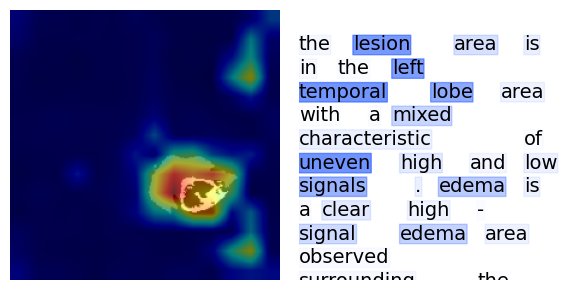

In [14]:
vmap = plot(model, image_path, text)

In [15]:
from sklearn.cluster import KMeans

In [16]:
kmeans = KMeans(n_clusters=2,random_state=10)
attn_weights = vmap / 255
# Keep only high attention weight scores
h, w = attn_weights.shape
filtered_attn_weights = attn_weights > 0.4
attn_weights = attn_weights*filtered_attn_weights
image = cv2.resize(attn_weights, (256, 256),interpolation=cv2.INTER_NEAREST)
flat_image = image.reshape(-1, 1)

In [17]:
labels = kmeans.fit_predict(flat_image)

In [18]:
segmented_image = labels.reshape(256, 256)

In [19]:
centroids = kmeans.cluster_centers_.flatten()

In [20]:
# Identify the background cluster (assuming it has the lowest centroid value)
background_cluster = np.argmin(centroids)

In [21]:
# Mark background pixels as 0 and foreground pixels as 1
segmented_image = np.where(segmented_image == background_cluster, 0, 1)

In [22]:
segmented_image = cv2.resize(segmented_image, (w,h),interpolation=cv2.INTER_NEAREST)
segmented_image = segmented_image.astype(np.uint8)*255

In [23]:
nb_blobs, im_with_separated_blobs, stats, _ = cv2.connectedComponentsWithStats(segmented_image)
sizes = stats[:, cv2.CC_STAT_AREA]

In [24]:
# Sort sizes (ignoring the background at index 0)
sorted_sizes = sorted(sizes[1:], reverse=True)

In [25]:
# Change this here if you want to segment more than one contour
num_contours = 1

In [26]:
# Determine the top K sizes
top_k_sizes = sorted_sizes[:num_contours]

In [27]:
im_result = np.zeros_like(im_with_separated_blobs)

In [28]:
for index_blob in range(1, nb_blobs):
    if sizes[index_blob] in top_k_sizes:
        im_result[im_with_separated_blobs == index_blob] = 255

In [29]:
segmented_image = im_result

In [51]:
%ls /home/amina/amina/ws-bt-prelim/spring_03/resume/MedCLIP-SAMv2/MedCLIP-SAMv2

assets/                        loss/                 segment-anything/
biomedclip_finetuning/         medclipsamv2_env.yml  weak_segmentation/
biomedclip_vit_bert_hf_local/  postprocessing/       zeroshot_scripts/
evaluation/                    README.md             zeroshot.sh
LICENSE                        saliency_maps/


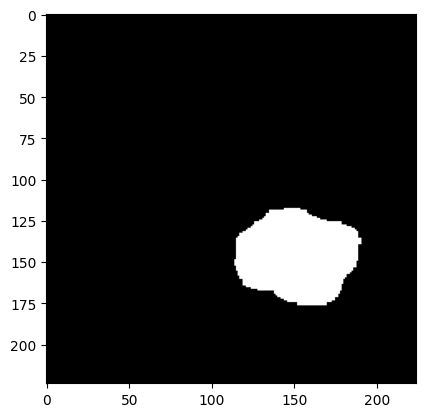

In [66]:
plt.imshow(segmented_image,cmap="gray")

In [54]:
segmented_image = segmented_image.astype(np.float32)

# normalize to [0, 255]
segmented_image = (segmented_image - segmented_image.min()) / (segmented_image.max() - segmented_image.min() + 1e-8)
segmented_image = (segmented_image * 255).astype(np.uint8)

cv2.imwrite("postprocessed_map.png", segmented_image)

True

In [55]:
%ls ../../../../resume/MedCLIP-SAMv2/MedCLIP-SAMv2/segment-anything

CODE_OF_CONDUCT.md  prompt_sam.py      segment_anything.egg-info/
CONTRIBUTING.md     scripts/           setup.cfg
linter.sh           segment_anything/  setup.py


In [ ]:
#@title Step 3: SAM Output

import sys
sys.path.append("../../../../resume/MedCLIP-SAMv2/MedCLIP-SAMv2/segment-anything")
from segment_anything import sam_model_registry, SamPredictor
_CONTOUR_INDEX = 1 if cv2.__version__.split('.')[0] == '3' else 0

In [57]:
def scoremap2bbox(scoremap, multi_contour_eval=False):
    height, width = scoremap.shape
    scoremap_image = (scoremap * 255).astype(np.uint8)
    contours, _ = cv2.findContours(
        image=scoremap_image,
        mode=cv2.RETR_EXTERNAL,
        method=cv2.CHAIN_APPROX_SIMPLE)

    num_contours = len(contours)

    if len(contours) == 0:
        return np.asarray([[0, 0, width, height]]), 1


    if not multi_contour_eval:
        # contours = [max(contours, key=cv2.contourArea)]
        contours = [np.concatenate(contours)]

    estimated_boxes = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        x0, y0, x1, y1 = x, y, x + w, y + h
        x1 = min(x1, width - 1)
        y1 = min(y1, height - 1)
        estimated_boxes.append([x0, y0, x1, y1])

    return estimated_boxes, contours,num_contours

In [58]:
sam_checkpoint = "/home/amina/amina/ws-bt-prelim/spring_03/resume/MedCLIP-SAMv2/MedCLIP-SAMv2/segment-anything/segment_anything/sam_vit_h_4b8939.pth"
model_type = "vit_h"
device = "cpu"

In [59]:
prompts = "boxes" #@param ["boxes", "points","both"]
pos_num_points = 10 # @param {type:"integer"}
neg_num_points = 2 # @param {type:"integer"}

In [60]:
%ls /home/amina/amina/ws-bt-prelim/spring_03/resume/MedCLIP-SAMv2/MedCLIP-SAMv2/segment-anything/segment_anything

automatic_mask_generator.py  __init__.py  predictor.py  sam_vit_h_4b8939.pth*
build_sam.py                 modeling/    __pycache__/  utils/


In [61]:
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)

In [62]:
sam.to(device=device)

Sam(
  (image_encoder): ImageEncoderViT(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 1280, kernel_size=(16, 16), stride=(16, 16))
    )
    (blocks): ModuleList(
      (0-31): 32 x Block(
        (norm1): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=1280, out_features=3840, bias=True)
          (proj): Linear(in_features=1280, out_features=1280, bias=True)
        )
        (norm2): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (lin1): Linear(in_features=1280, out_features=5120, bias=True)
          (lin2): Linear(in_features=5120, out_features=1280, bias=True)
          (act): GELU(approximate='none')
        )
      )
    )
    (neck): Sequential(
      (0): Conv2d(1280, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): LayerNorm2d()
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (3): LayerNorm2d

In [64]:
predictor = SamPredictor(sam)
predictor

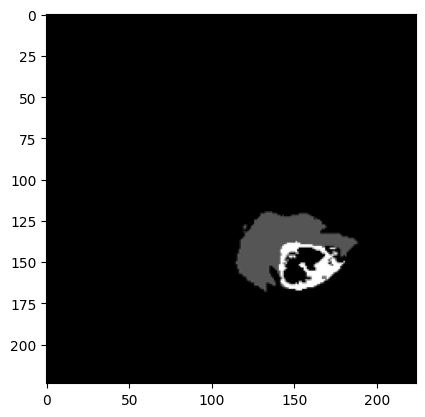

In [65]:
img = cv2.imread(image_path)
plt.imshow(img, cmap="gray")

In [72]:
mask = cv2.imread(f"postprocessed_map.png", cv2.IMREAD_GRAYSCALE)

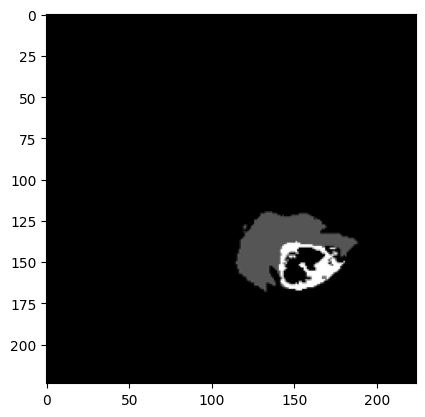

In [73]:
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img, cmap="gray")

In [74]:
predictor.set_image(img)

In [75]:
# Change Multicontour to True if you have more than one contour to segment
bounding_boxes, contours, num_contours = scoremap2bbox(mask, multi_contour_eval=False)

In [76]:
if prompts == "boxes":
  bounding_boxes = np.array(bounding_boxes)
  input_boxes = torch.tensor(bounding_boxes, device=device)
  transformed_boxes = predictor.transform.apply_boxes_torch(input_boxes, img.shape[:2])
  masks, scores, _ = predictor.predict_torch(
      point_coords=None,
      point_labels=None,
      boxes=transformed_boxes,
      multimask_output=False
  )
  masks = masks.cpu().numpy()
elif prompts == "points":
  pos_random_points = []
  neg_random_points = []
  candidate_points = np.argwhere(mask.transpose(1,0) > 0)
  h,w = mask.shape
  random_index = np.random.choice(len(candidate_points), pos_num_points, replace=False)
  pos_random_points = candidate_points[random_index]

  candidate_points = np.argwhere(mask.transpose(1,0) == 0)
  random_index = np.random.choice(len(candidate_points), neg_num_points, replace=False)
  neg_random_points = candidate_points[random_index]
  all_random_points = np.concatenate([pos_random_points,neg_random_points])
  all_input_labels = [1]*len(pos_random_points) + [0]*len(neg_random_points)
  masks, scores, _ = predictor.predict(
            point_coords=all_random_points,
            point_labels=all_input_labels,
            multimask_output=False,
        )
else:
  input_boxes = torch.tensor(bounding_boxes, device=device)
  pos_random_points = []
  neg_random_points = []
  candidate_points = np.argwhere(mask.transpose(1,0) > 0)
  h,w = mask.shape
  random_index = np.random.choice(len(candidate_points), pos_num_points, replace=False)
  pos_random_points = candidate_points[random_index]
  candidate_points = np.argwhere(mask.transpose(1,0) == 0)
  random_index = np.random.choice(len(candidate_points), neg_num_points, replace=False)
  neg_random_points = candidate_points[random_index]
  all_random_points = np.concatenate([pos_random_points,neg_random_points])
  all_input_labels = [1]*len(pos_random_points) + [0]*len(neg_random_points)
  input_points = torch.tensor(all_random_points, device=device)
  input_labels = torch.tensor(all_input_labels, device=device)
  input_points = input_points.repeat((len(bounding_boxes),1,1))
  input_labels = input_labels.repeat((len(bounding_boxes),1))
  transformed_boxes = predictor.transform.apply_boxes_torch(input_boxes, image.shape[:2])
  transformed_points = predictor.transform.apply_coords_torch(input_points, image.shape[:2])
  masks, scores, _ = predictor.predict_torch(
      point_coords=transformed_points,
      point_labels=input_labels,
      boxes=transformed_boxes,
      multimask_output=False
  )
  masks = masks.cpu().numpy()

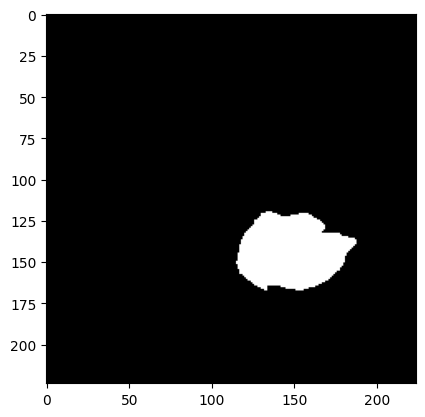

In [77]:
output = "/content/MedCLIP-SAMv2/sam_output.png"
mask_sam = np.squeeze(masks*255).astype('uint8')
cv2.imwrite(output,mask_sam)
plt.imshow(mask_sam,cmap="gray")

In [83]:
%ls /home/amina/amina/ws-bt-prelim/spring_03/prototype/dataset/BraTS20_Training_004

BraTS20_Training_004_flair.nii       BraTS20_Training_004_flair_text.txt
BraTS20_Training_004_flair_text.npy  BraTS20_Training_004_seg.nii


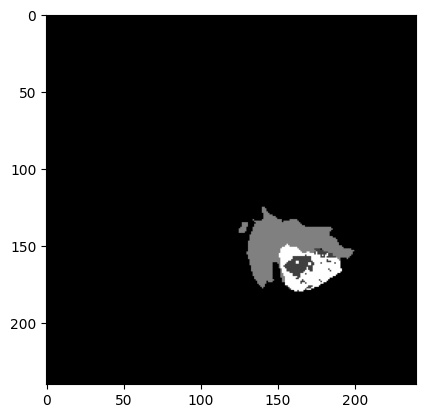

In [96]:
import nibabel as nib
import matplotlib.pyplot as plt

nii = nib.load("/home/amina/amina/ws-bt-prelim/spring_03/prototype/dataset/BraTS20_Training_004/BraTS20_Training_004_seg.nii")
volume = nii.get_fdata()

# middle axial slice
z = volume.shape[2] // 2
slice_2d = volume[:, :, z]

plt.imshow(slice_2d, cmap="gray")
plt.axis("on")
plt.show()